# Regression with K-Fold Cross Validation

Wine quality regression using an MLP trained with **5-fold stratified cross-validation**. Each fold produces an independent experiment; the best fold (by validation MSE) is selected and evaluated on a held-out test set.

**Key design choices:**
- `StratifiedKFold` to preserve the quality score distribution across folds
- Per-fold min-max normalization computed exclusively from that fold's training split — no data leakage
- Early stopping with best-checkpoint restoration per fold
- `ReduceLROnPlateau` scheduler and L2 weight decay for smoother convergence
- Final metrics (MSE, RMSE, MAPE) are denormalized back to the original quality scale (3–8)

In [1]:
import os

import torch
import torch.nn as nn
import torch.utils.data as data_utils

import random
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from dataclasses import dataclass, field

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED);

## Dataset

The Wine Quality dataset was explored in detail in the previous notebook (`RegressionWithValidation.ipynb`). It contains 11 physicochemical features (acidity, sulphates, alcohol, etc.) and an integer quality score (3–8) as the target.

A stratified 90/10 split reserves a **held-out test set** that is never seen during fold training or fold selection. The remaining 90% (`X_train_val`) feeds into `StratifiedKFold`, which preserves the quality score class distribution across every fold.

In [3]:
df = pd.read_csv('data/winequality/WineQT.csv')
# drop id column
df = df.drop(columns='Id', axis=1)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
X = df[df.columns[:-1]]
y = pd.DataFrame(df['quality'].values, columns=['quality'])

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=.10, random_state=SEED,
    stratify=y
)

In [5]:
print(X_train_val.shape, y_train_val.shape)
print(X_test.shape, y_test.shape)

(1028, 11) (1028, 1)
(115, 11) (115, 1)


## Model & Experiment Design

### Architecture — `DropoutModel`
A four-layer MLP with Dropout (p=0.2) after each hidden activation:

```
Linear(11 → 256) → ReLU → Dropout(0.2)
Linear(256 → 128) → ReLU → Dropout(0.2)
Linear(128 → 64)  → ReLU → Dropout(0.2)
Linear(64 → 1)
```

### `Experiment` dataclass
Bundles the model, optimizer, scheduler, early-stopping config, and per-fold normalization statistics (`min_df`, `max_df`, `min_t`, `max_t`) into a single object. `__post_init__` instantiates the optimizer (with L2 weight decay) and wraps it with `ReduceLROnPlateau`, so each fold starts from a clean state.

In [6]:
@dataclass
class Experiment:
    "Represents a model and all its hyperparameters for a given experiment"

    name: str
    checkpoints_folder: str
    checkpoint_name: str
    model: object
    use_early_stopping: bool
    loss_fn: object
    optimizer: object
    color: str
    alpha: float
    scheduler: object
    weight_decay: float = None
    max_df: float = None
    min_df: float = None
    max_t: float = None
    min_t: float = None
    checkpoint_save_path: str = None
    val_mse: float = None
    lr: float = 1e-5
    epochs: int = 600
    patience: int = 10
    min_delta: float = 0
    epochs_count: list = field(default_factory = list)
    train_loss_values: list = field(default_factory = list)
    val_loss_values: list = field(default_factory = list)
    plt_arg_training: list = field(default_factory = list)
    plt_args_validation: list = field(default_factory = list)
    
    def __post_init__(self):
        self.optimizer = self.optimizer(
            params= self.model.parameters(), 
            lr = self.lr,
            weight_decay=self.weight_decay
        )

        self.scheduler = self.scheduler(
            optimizer=self.optimizer,
            patience=10,
            factor=0.5
        )
        
        self.checkpoints_folder = os.path.join(self.checkpoints_folder, self.name)
        os.makedirs(self.checkpoints_folder, exist_ok=True)
        self.checkpoint_save_path = os.path.join(self.checkpoints_folder, self.checkpoint_name)


In [7]:
class EarlyStopping:
    def __init__(self, save_path, patience=5, min_delta=0):
        super().__init__()

        self.save_path = save_path
        self.patience = patience
        self.min_delta = min_delta
        self.min_val_loss = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, validation_loss, model):

        if self.min_val_loss is None:  # first epoch
            self.min_val_loss = validation_loss
            self.save_checkpoint(model)
        
        elif (self.min_val_loss - validation_loss) > self.min_delta:   # the model is getting better
            self.min_val_loss = validation_loss
            self.save_checkpoint(model)
            self.counter = 0
        
        else: # the model is not getting better
            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.save_path)

In [8]:
class DropoutModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(in_features=11, out_features=256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(in_features=256, out_features=128),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(in_features=128, out_features=64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(in_features=64, out_features=1)
        )

    def forward(self, x):
        return self.net(x)

## Training Utilities

- **`EarlyStopping`** — monitors validation loss, saves the best checkpoint, and halts training when no improvement exceeds `min_delta` for `patience` consecutive epochs.
- **`train_experiment`** — runs the full training loop; steps `ReduceLROnPlateau` once per epoch on the epoch-average validation loss; restores the best checkpoint after early stopping.
- **`test_experiment`** — returns mean MSE over a DataLoader (used to record each fold's validation MSE for fold selection).
- **`evaluate_experiment`** — denormalizes predictions and targets using the fold's stored scaler bounds, then computes MSE, RMSE, and MAPE on the original quality scale.
- **`normalize_data`** — fits a min-max scaler on the fold's training split only and applies it to train / val / test; scaler bounds are stored directly on the `Experiment` object for later denormalization.
- **`create_dataloaders`** — wraps split DataFrames into `TensorDataset` / `DataLoader` objects.

In [9]:
def train_experiment(exp: Experiment, train_loader, val_loader):
    exp.epochs_count = []
    exp.train_loss_values = []
    exp.val_loss_values = []

    if exp.use_early_stopping:
        early_stopping = EarlyStopping(
            exp.checkpoint_save_path, 
            exp.patience,
            min_delta = exp.min_delta
        )
    
    for epoch in range(exp.epochs):
        exp.model.train()

        train_loss_epoch = 0
        for i, data in enumerate(train_loader, 0):
            X = data[0]
            y = data[1]

            exp.optimizer.zero_grad()
            y_pred = exp.model(X)
            train_loss = exp.loss_fn(y_pred, y)
            train_loss_epoch += train_loss
            train_loss.backward()
            exp.optimizer.step()
        
        exp.model.eval()
        val_loss_epoch = 0
        for j, data in enumerate(val_loader, 0):
            X = data[0]
            y = data[1]
            with torch.no_grad():
                y_pred = exp.model(X)
                val_loss = exp.loss_fn(y_pred, y)
            val_loss_epoch += val_loss
            
        exp.epochs_count.append(epoch)
        exp.train_loss_values.append(train_loss_epoch.detach().numpy()/len(train_loader))
        exp.val_loss_values.append(val_loss_epoch.detach().numpy()/len(val_loader))
        print(f"Epoch: {epoch:<4}  |  Train Loss: {train_loss_epoch/len(train_loader):.6f}  |  Val Loss: {val_loss_epoch/len(val_loader):.6f}")

        exp.scheduler.step(val_loss_epoch / len(val_loader))

        if exp.use_early_stopping:
            early_stopping(val_loss_epoch/len(val_loader), exp.model)
            if early_stopping.early_stop:
                print(f"Early stopping at epoch: {epoch}")
                break

    if exp.use_early_stopping:
        exp.model.load_state_dict(torch.load(exp.checkpoint_save_path))


In [10]:
def test_experiment(exp: Experiment, test_loader):
    tot_loss = 0
    exp.model.eval()
    for j, data in enumerate(test_loader, 0):

        X = data[0]
        y = data[1]

        with torch.no_grad():
            y_pred = exp.model(X)
            loss = exp.loss_fn(y_pred, y)

        tot_loss += loss
    
    return tot_loss.detach().numpy()/len(test_loader)

In [11]:
def evaluate_experiment(exp, loader):
    scale = float(exp.max_t.values[0] - exp.min_t.values[0])
    offset = float(exp.min_t.values[0])

    exp.model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X, y in loader:
            all_preds.append(exp.model(X))
            all_targets.append(y)

    preds   = torch.cat(all_preds).squeeze()   * scale + offset
    targets = torch.cat(all_targets).squeeze() * scale + offset

    mse  = float(((preds - targets) ** 2).mean())
    rmse = mse ** 0.5
    mape = float(((preds - targets).abs() / targets).mean() * 100)
    return mse, rmse, mape

In [12]:
def plot_loss(exp: Experiment, warmup=5):
    ec = exp.epochs_count
    tl = exp.train_loss_values
    vl = exp.val_loss_values

    TRAIN_COLOR = '#ff7f0e'
    VAL_COLOR = '#4D61E2'

    best_idx = len(ec) - exp.patience - 1 if exp.use_early_stopping else None

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, slice_start in [(axes[0], 0), (axes[1], warmup)]:
        ec_s = ec[slice_start:]
        tl_s = tl[slice_start:]
        vl_s = vl[slice_start:]

        if best_idx is not None:
            local_best = max(0, best_idx - slice_start)

            ax.plot(ec_s[:local_best + 1], tl_s[:local_best + 1], color=TRAIN_COLOR, alpha=1.0, label='Training')
            ax.plot(ec_s[:local_best + 1], vl_s[:local_best + 1], color=VAL_COLOR, alpha=1.0, label='Validation')

            if local_best < len(ec_s) - 1:
                ax.plot(ec_s[local_best:], tl_s[local_best:], color=TRAIN_COLOR, alpha=0.3)
                ax.plot(ec_s[local_best:], vl_s[local_best:], color=VAL_COLOR, alpha=0.3)
        else:
            ax.plot(ec_s, tl_s, color=TRAIN_COLOR, alpha=1.0, label='Training')
            ax.plot(ec_s, vl_s, color=VAL_COLOR, alpha=1.0, label='Validation')

        if slice_start > 0:
            ax.fill_between(ec_s, tl_s, vl_s, alpha=0.15, color='red', label='Overfit gap')

        ax.legend(loc='upper right')
        ax.grid(alpha=0.3)

    axes[0].set_yscale('log')
    axes[0].set_title(f'{exp.name} — MSE (log scale)')
    axes[1].set_title(f'{exp.name} — MSE (after warmup, epoch {warmup}+)')

    plt.tight_layout()
    plt.show()

In [13]:
def normalize_data(X_train, X_val, X_test, y_train, y_val, y_test, exp):
    max_df = X_train.max()
    min_df = X_train.min()
    exp.max_df = max_df
    exp.min_df = min_df

    max_t = y_train.max()
    min_t = y_train.min()
    exp.max_t = max_t
    exp.min_t = min_t

    X_train_norm = (X_train-min_df)/(max_df-min_df)
    X_val_norm = (X_val - min_df)/(max_df-min_df)
    X_test_norm = (X_test-min_df)/(max_df-min_df)

    y_train_norm = (y_train-min_t)/(max_t-min_t)
    y_val_norm = (y_val-min_t)/(max_t-min_t)
    y_test_norm = (y_test-min_t)/(max_t-min_t)

    return X_train_norm, X_val_norm, X_test_norm, y_train_norm, y_val_norm, y_test_norm

In [14]:
def create_dataloaders(X_train, X_val, X_test, y_train, y_val, y_test, batch_size=32):
    train_dataset = data_utils.TensorDataset(torch.tensor(X_train.values, dtype=torch.float32), 
                                    torch.tensor(y_train.values, dtype=torch.float32))
    train_loader = data_utils.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


    test_dataset = data_utils.TensorDataset(torch.tensor(X_test.values, dtype=torch.float32), 
                                    torch.tensor(y_test.values, dtype=torch.float32))
    test_loader = data_utils.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


    val_dataset = data_utils.TensorDataset(torch.tensor(X_val.values, dtype=torch.float32), 
                                    torch.tensor(y_val.values, dtype=torch.float32))
    val_loader = data_utils.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [15]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau

epochs = 1000

## K-Fold Cross Validation

`StratifiedKFold(n_splits=5)` partitions `X_train_val` into five folds. Each fold runs as an independent experiment:

1. **Normalize** — fit the min-max scaler on this fold's train indices only; transform train, val, and test splits.
2. **Train** — run `train_experiment` with early stopping (patience=50); the best checkpoint is restored automatically at the end.
3. **Record val MSE** — evaluated on the normalized validation split; used later to select the best fold.

The held-out test set is never used for training or fold selection — only for the final denormalized evaluation.

In [16]:
experiments = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_val, y_train_val)):
    train_loss_values_fold = []
    val_loss_values_fold = []
    epochs_count_fold = []
    exp_fold = Experiment(
        name=f"Dropout-{fold}",
        checkpoints_folder='models_kfold',
        checkpoint_name='model.pt', 
        model=DropoutModel(), 
        use_early_stopping=True, 
        loss_fn=loss_fn, 
        optimizer=optimizer,
        scheduler=scheduler,
        lr=1e-3,
        weight_decay=1e-4,
        epochs=epochs,
        patience=50, 
        epochs_count=epochs_count_fold, 
        train_loss_values=train_loss_values_fold, 
        val_loss_values=val_loss_values_fold,
        alpha=.8,
        color="#363eb9"
    )

    experiments.append(exp_fold)

    X_train_fold, X_val_fold, X_test_fold, y_train_fold, y_val_fold, y_test_fold = normalize_data(
        X_train_val.iloc[train_idx], 
        X_train_val.iloc[val_idx],
        X_test,
        y_train_val.iloc[train_idx],
        y_train_val.iloc[val_idx],
        y_test,
        exp_fold
    )

    train_loader, val_loader, test_loader = create_dataloaders(
        X_train_fold, X_val_fold, X_test_fold, y_train_fold, y_val_fold, y_test_fold
    )

    train_experiment(
        exp=exp_fold,
        train_loader=train_loader,
        val_loader=val_loader
    )

    exp_fold.val_mse = test_experiment(
        exp=exp_fold,
        test_loader=val_loader
    )


Epoch: 0     |  Train Loss: 0.071759  |  Val Loss: 0.031096
Epoch: 1     |  Train Loss: 0.027543  |  Val Loss: 0.018896
Epoch: 2     |  Train Loss: 0.024443  |  Val Loss: 0.017673
Epoch: 3     |  Train Loss: 0.023941  |  Val Loss: 0.017951
Epoch: 4     |  Train Loss: 0.020479  |  Val Loss: 0.016112
Epoch: 5     |  Train Loss: 0.020288  |  Val Loss: 0.016163
Epoch: 6     |  Train Loss: 0.021095  |  Val Loss: 0.016851
Epoch: 7     |  Train Loss: 0.020235  |  Val Loss: 0.019271
Epoch: 8     |  Train Loss: 0.019610  |  Val Loss: 0.016325
Epoch: 9     |  Train Loss: 0.021594  |  Val Loss: 0.016181
Epoch: 10    |  Train Loss: 0.021122  |  Val Loss: 0.021120
Epoch: 11    |  Train Loss: 0.019052  |  Val Loss: 0.016883
Epoch: 12    |  Train Loss: 0.019474  |  Val Loss: 0.016523
Epoch: 13    |  Train Loss: 0.020139  |  Val Loss: 0.016390
Epoch: 14    |  Train Loss: 0.021549  |  Val Loss: 0.016985
Epoch: 15    |  Train Loss: 0.019921  |  Val Loss: 0.016078
Epoch: 16    |  Train Loss: 0.018243  | 

## Results & Evaluation

Loss curves are plotted for each fold (full log-scale and post-warmup). The fold with the lowest validation MSE is selected as the best model. Its normalization statistics are used to transform the held-out test set, and denormalized MSE, RMSE, and MAPE are reported on the original quality scale.

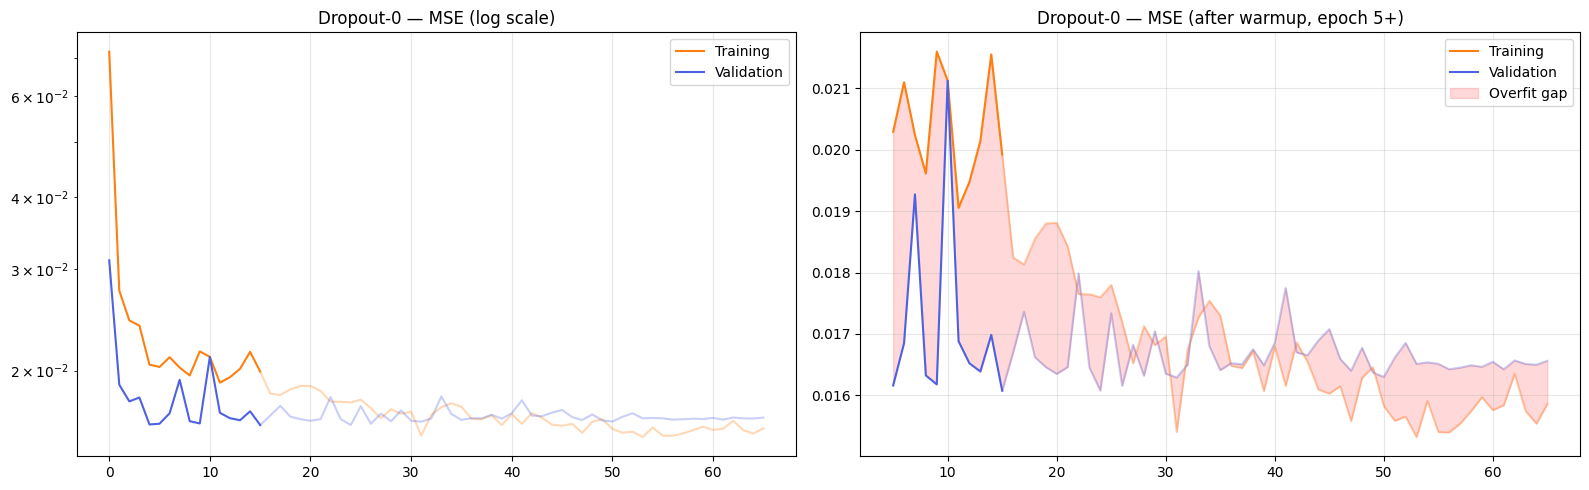

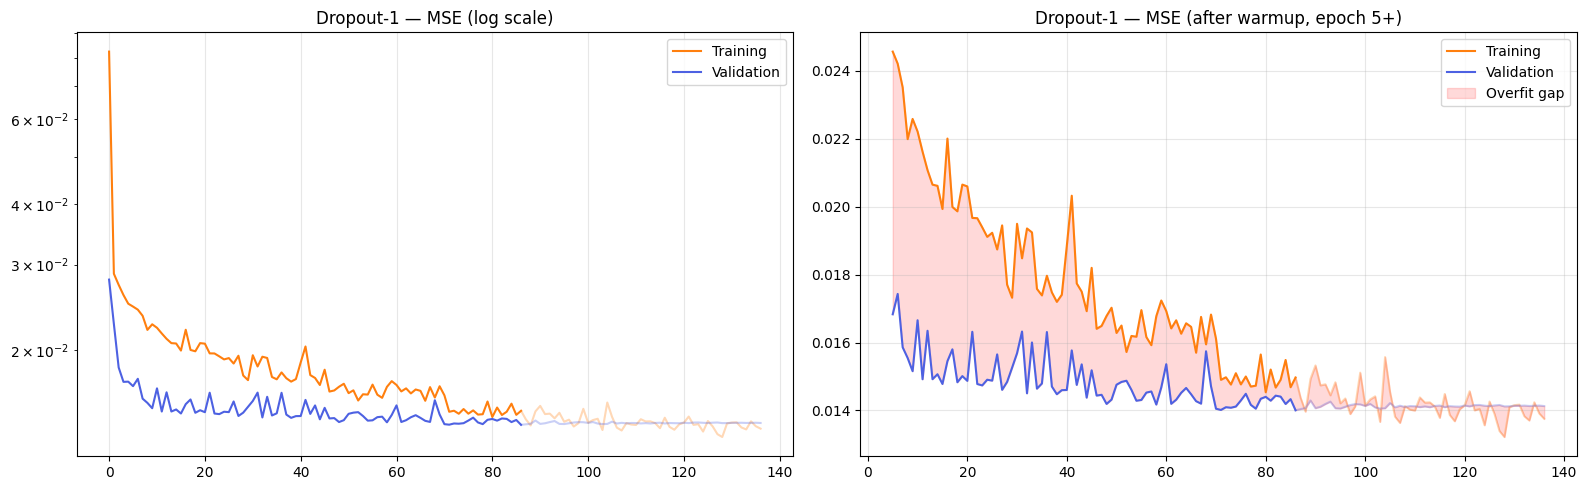

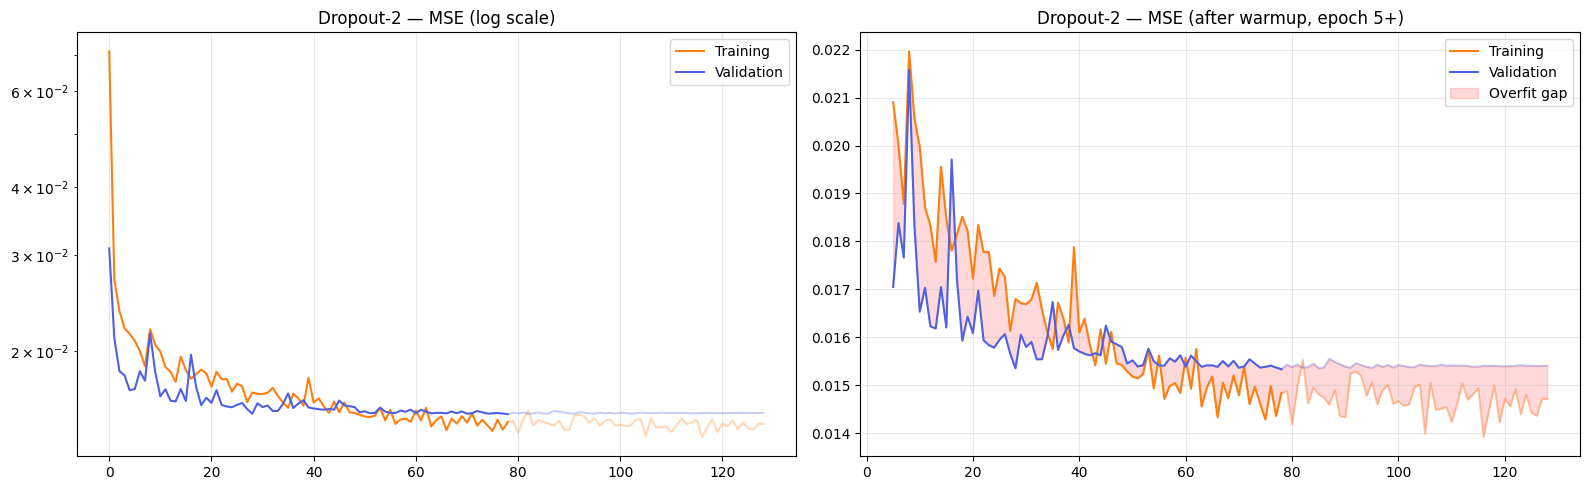

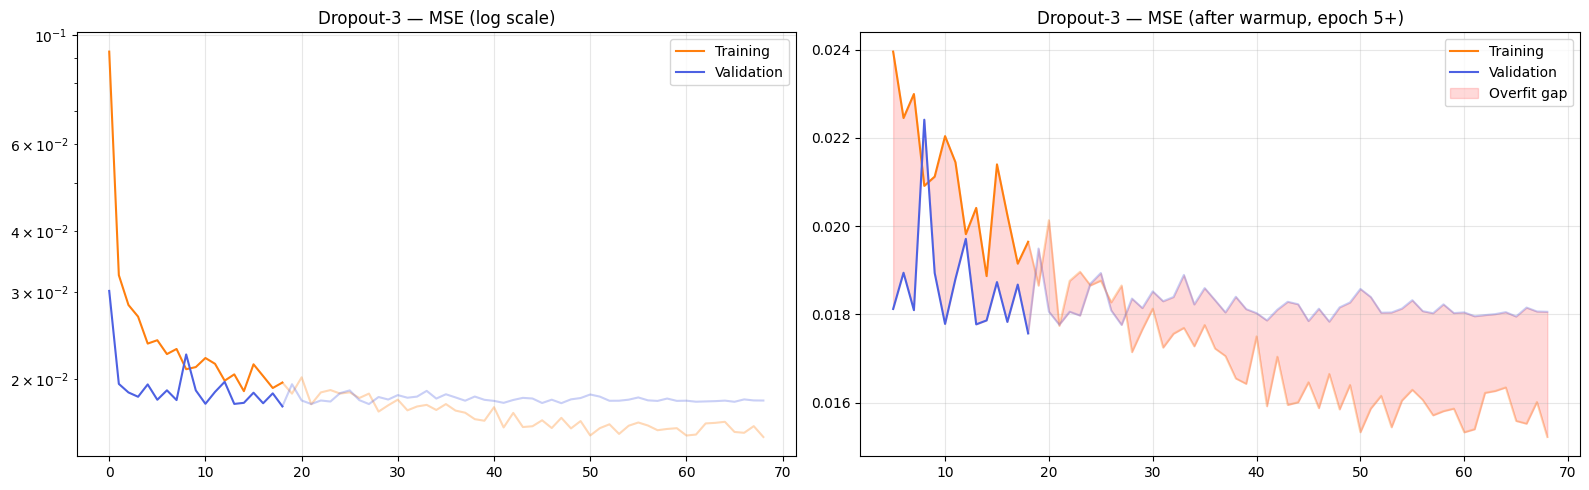

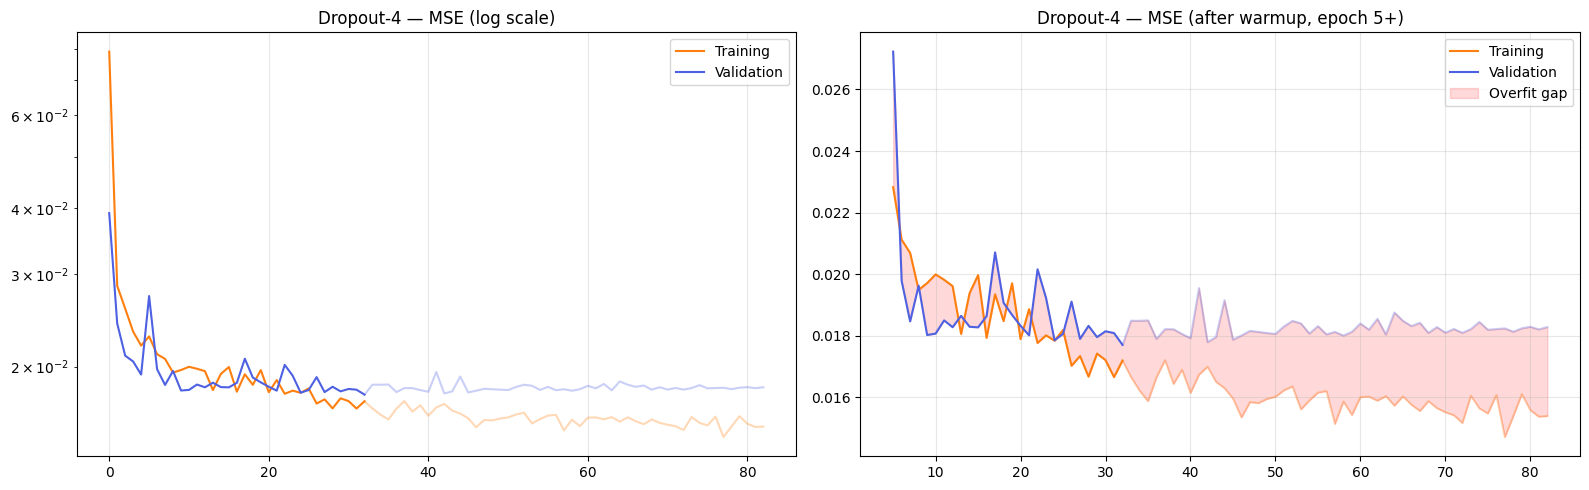

Fold               Val MSE
---------------------------
Dropout-0         0.016078
Dropout-1         0.014006
Dropout-2         0.015336
Dropout-3         0.017570
Dropout-4         0.017702
---------------------------
Mean              0.016138
Std               0.001392

Best fold: Dropout-1  (val MSE: 0.014006)

Experiment             Test MSE    Test RMSE       MAPE
--------------------------------------------------------
Dropout-1                0.4195       0.6477      8.57%


In [17]:
# Loss curves per fold
for exp in experiments:
    plot_loss(exp)

# Per-fold val MSE summary
val_mses = [exp.val_mse for exp in experiments]

print(f"{'Fold':<15} {'Val MSE':>10}")
print("-" * 27)
for exp in experiments:
    print(f"{exp.name:<15} {exp.val_mse:>10.6f}")
print("-" * 27)
print(f"{'Mean':<15} {np.mean(val_mses):>10.6f}")
print(f"{'Std':<15} {np.std(val_mses):>10.6f}")

# Select best fold by val MSE
best_exp = min(experiments, key=lambda x: x.val_mse)
print(f"\nBest fold: {best_exp.name}  (val MSE: {best_exp.val_mse:.6f})")

# Recreate normalized test set using best fold's normalization stats
X_test_norm = (X_test - best_exp.min_df) / (best_exp.max_df - best_exp.min_df)
y_test_norm = (y_test - best_exp.min_t)  / (best_exp.max_t  - best_exp.min_t)

test_dataset = data_utils.TensorDataset(
    torch.tensor(X_test_norm.values, dtype=torch.float32),
    torch.tensor(y_test_norm.values, dtype=torch.float32)
)
test_loader = data_utils.DataLoader(test_dataset, batch_size=32, shuffle=False)

# Denormalized evaluation on test set
mse, rmse, mape = evaluate_experiment(best_exp, test_loader)

print(f"\n{'Experiment':<20} {'Test MSE':>10} {'Test RMSE':>12} {'MAPE':>10}")
print("-" * 56)
print(f"{best_exp.name:<20} {mse:>10.4f} {rmse:>12.4f} {mape:>9.2f}%")
